In [33]:
###import the necessory package

In [1]:
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Flatten, MaxPool2D, Input
from keras.datasets import fashion_mnist

In [2]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [3]:
x_train.shape

(60000, 28, 28)

In [4]:
x_test.shape

(10000, 28, 28)

In [5]:
img = x_train[1]

In [6]:
img

array([[  0,   0,   0,   0,   0,   1,   0,   0,   0,   0,  41, 188, 103,
         54,  48,  43,  87, 168, 133,  16,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   1,   0,   0,   0,  49, 136, 219, 216, 228, 236,
        255, 255, 255, 255, 217, 215, 254, 231, 160,  45,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,  14, 176, 222, 224, 212, 203, 198, 196,
        200, 215, 204, 202, 201, 201, 201, 209, 218, 224, 164,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 188, 219, 200, 198, 202, 198, 199, 199,
        201, 196, 198, 198, 200, 200, 200, 200, 201, 200, 225,  41,   0,
          0,   0],
       [  0,   0,   0,   0,  51, 219, 199, 203, 203, 212, 238, 248, 250,
        245, 249, 246, 247, 252, 248, 235, 207, 203, 203, 222, 140,   0,
          0,   0],
       [  0,   0,   0,   0, 116, 226, 206, 204, 207, 204, 101,  75,  47,
         73,  48,  50,  45,  51,  63, 113, 222, 202, 206, 220, 224,   0,
          0,   0],
       [  

In [7]:
import matplotlib.pyplot as plt

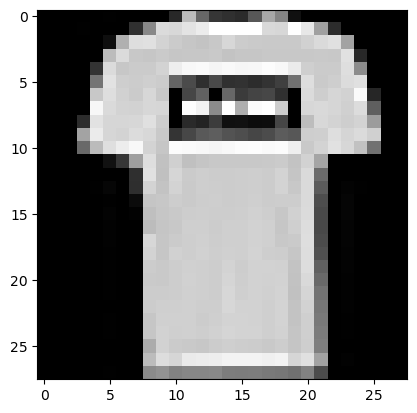

In [8]:
plt.imshow(img, cmap='gray');

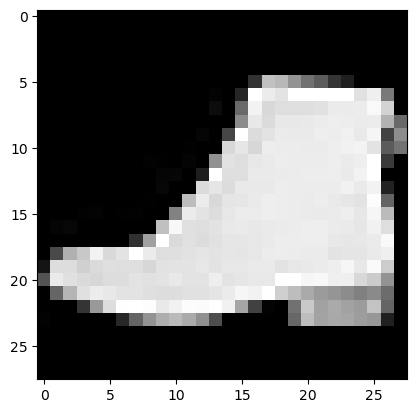

In [9]:
img = x_train[7000]
plt.imshow(img, cmap='gray');

In [10]:
labels = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
          'Sandal','Shirt','Sneaker','Bag','Ankle boot']

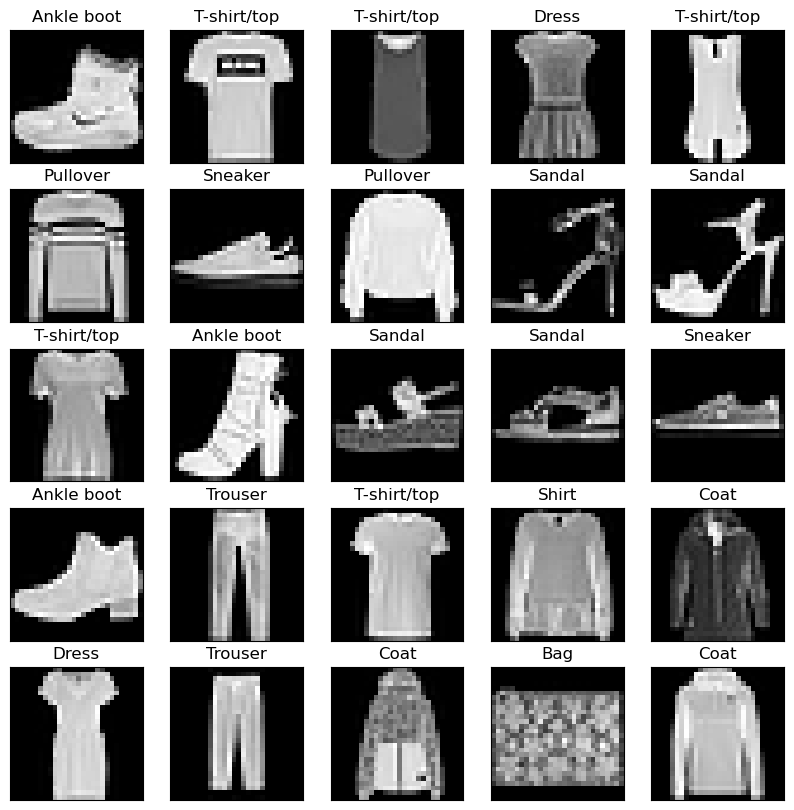

In [11]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.title(labels[y_train[i]])
    plt.imshow(x_train[i], cmap = 'gray')
    

In [12]:
import pandas as pd
pd.Series(y_train).value_counts()

9    6000
0    6000
3    6000
2    6000
7    6000
5    6000
1    6000
6    6000
4    6000
8    6000
Name: count, dtype: int64

In [13]:
#one hot encoding of output variable
from keras.utils import to_categorical
y_train_new = to_categorical(y_train)
y_test_new = to_categorical(y_test)

In [14]:
y_train_new.shape

(60000, 10)

In [15]:
y_train_new

array([[0., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [16]:
import numpy as np

In [17]:
arr = np.array([[6,7,8],[8,4,2],[0,1,2]])
arr

array([[6, 7, 8],
       [8, 4, 2],
       [0, 1, 2]])

In [18]:
arr.flatten()

array([6, 7, 8, 8, 4, 2, 0, 1, 2])

In [19]:
###Define the network architecture using keras

In [20]:
# Create the object of neural network
model = Sequential()

# Add the input layer
model.add(Input((28,28,1)))

# Add convolutional layer - 1
model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))

#pooling layer-1
model.add(MaxPool2D(pool_size=(2,2)))

#Add convolutional layer-2
model.add(Conv2D(filters=16, kernel_size=(3,3), activation='relu'))

#pooling layer-2
model.add(MaxPool2D(pool_size=(2,2)))

#Add flatten layer
model.add(Flatten())

# Add Hidden layer
model.add(Dense(128,activation='relu'))

# Add output layer
model.add(Dense(10,activation='softmax'))

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        51,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,562 (224.85 KB)

 Trainable params: 57,562 (224.85 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
from keras.optimizers import SGD

In [23]:
model.compile(loss = 'categorical_crossentropy',optimizer=SGD(),
              metrics=['accuracy'])

In [24]:
history = model.fit (x_train, y_train_new, epochs=10, batch_size=10)

Epoch 1/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.1003 - loss: 1872183077577386383028256768.0000  
Epoch 2/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.0986 - loss: 2.3029
Epoch 3/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.0993 - loss: 2.3028
Epoch 4/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.1003 - loss: 2.3028
Epoch 5/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.1011 - loss: 2.3028
Epoch 6/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.1003 - loss: 2.3029
Epoch 7/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.0991 - loss: 2.3029
Epoch 8/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.0985 - loss: 2.3029
Epoch 9/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.0971 - loss: 2.3029
Epoch 10/10
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.0981 - loss: 2.3029


In [25]:
####Evaluate the network

In [ ]:
model.evaluate(x_test, y_test_new, batch_size=1)